# Order asymmetry: rule-governed facts against retrieval facts

`n×0` is answered slower than `0×n` (see `rt_zero_direction.ipynb`). Is that a property of the zero, or
does every fact have an order effect? The same paired test is run on **all 45 pairs** of different
operands, in **two academic years independently** (ES_2025 and ES_2024, never pooled — DECISIONS #2),
and the effect sizes are compared. Source: A998, same filters (`DECISIONS.txt` #1–#11, #18–#19).
Query: `queries/rt_by_fact_correct.sql`.

**Convention** — within a pair the operands are ordered, so `2×3` means small operand first and `3×2`
large operand first. The difference is always `large-first − small-first`, which for a 0-fact is
`n×0 − 0×n`: positive means the large-first order is slower.

In [1]:
import gc, re, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu, spearmanr, theilslopes

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from cached_query import cached_query
from paired_stats import holm, signed_rank, stars
from plot_style import C_DIR, C_OTHER, C_ZERO, FONT_BIG, FONT_MED, paint_it_black, set_style

SQL_RT, SQL_CELLS = ROOT / "queries/rt_by_fact_correct.sql", ROOT / "queries/rt_error_by_fact_age.sql"
PLOTS = ROOT / "analysis" / "plots"; PLOTS.mkdir(exist_ok=True)
NAMED = ["2×3", "3×4", "6×8", "7×8", "8×9"]      # the easy / hard pairs asked for
RULE, ONE, RETR = "0 (rule)", "1 (rule)", "2-9 (retrieval)"
C_GROUP = {RULE: C_ZERO, ONE: C_DIR[1], RETR: C_OTHER}
YEARS = ["ES_2025", "ES_2024"]
MAIN = YEARS[0]
set_style()
fmt = lambda p: "< .001" if p < .001 else f"= {p:.3f}"

In [2]:
def _year(path, year):
    return re.sub(r"'[A-Z_0-9-]+'(\s+-- \{YEAR\})", f"'{year}'\\1", path.read_text(encoding="utf-8"))

def load_cells(year):
    '''The (age, operation) cells that clear the >= 30 rule, with their error rate (DECISIONS #11).'''
    return cached_query(SQL_CELLS, cache_dir=ROOT / "cache", sql_text=_year(SQL_CELLS, year))

def load_pairs(year):
    cells = load_cells(year)
    df = cached_query(SQL_RT, cache_dir=ROOT / "cache", sql_text=_year(SQL_RT, year))
    df = df[pd.MultiIndex.from_arrays([df.course_age, df.operation]).isin(set(zip(cells.course_age, cells.operation)))]
    lo = np.minimum(df.left_factor, df.right_factor); hi = np.maximum(df.left_factor, df.right_factor)
    return pd.DataFrame({                                    # downcast: millions of rows stay in memory
        "pair": pd.Categorical(lo.astype(str) + "×" + hi.astype(str)),
        "order": pd.Categorical(np.where(df.left_factor.eq(lo), "small_first", "large_first")),
        "student_uuid": pd.Categorical(df.student_uuid),
        "rt_seconds": df.rt_seconds.astype("float32")})

def pair_difficulty(cells):
    '''Error rate per pair -- difficulty measured independently of RT, from all responses.'''
    c = cells.assign(pair=np.minimum(cells.left_factor, cells.right_factor).astype(str) + "×"
                          + np.maximum(cells.left_factor, cells.right_factor).astype(str))
    c = c[c.left_factor.ne(c.right_factor)]
    g = c.groupby("pair")
    return (100 * g.n_errors.sum() / g.n_responses.sum()).rename("error_rate")

def group_of(index):
    return np.where(index.str.startswith("0×"), RULE, np.where(index.str.startswith("1×"), ONE, RETR))

def analyse(year):
    '''Everything one academic year contributes: the per-pair table and the rule-benefit numbers.'''
    df = load_pairs(year)
    w = (df.groupby(["pair", "student_uuid", "order"], observed=True).rt_seconds.median()
           .unstack("order").dropna())
    w["diff"] = w.large_first - w.small_first
    out = pd.DataFrame({p: signed_rank(g["diff"].to_numpy()) for p, g in w.groupby("pair", observed=True)}).T
    out["p_holm"] = holm(out.p.to_numpy())
    out["sig"] = [stars(x) for x in out.p_holm]
    out["group"] = group_of(out.index)
    out["med_diff_ms"] = 1000 * out.med_diff
    out = out.join(pair_difficulty(load_cells(year))).rename_axis("pair")

    gp = group_of(pd.Index(df.pair.astype(str)))
    m = (pd.DataFrame({"g": gp, "pos": df.order, "s": df.student_uuid, "rt": df.rt_seconds})
           .groupby(["s", "g", "pos"], observed=True).rt.median().unstack(["g", "pos"]))
    benefit = {}
    for g in (RULE, ONE):
        b = m[[(g, "small_first"), (g, "large_first"), (RETR, "small_first"), (RETR, "large_first")]].dropna()
        benefit[g] = {"benefit": signed_rank((b[RETR].mean(axis=1) - b[g].mean(axis=1)).to_numpy()),
                      "order": signed_rank((b[(g, "large_first")] - b[(g, "small_first")]).to_numpy())}
    meta = {"responses": len(df), "students": df.student_uuid.nunique(), "pairs": len(out),
            "student_pairs": len(w)}
    del df, w, m; gc.collect()
    return {"pairs": out, "benefit": benefit, "meta": meta}

R = {y: analyse(y) for y in YEARS}
for y in YEARS:
    print(f"{y}: {R[y]['meta']['responses']:,} responses | {R[y]['meta']['students']:,} students | "
          f"{R[y]['meta']['pairs']} pairs | {R[y]['meta']['student_pairs']:,} student × pair differences")
pairs = R[MAIN]["pairs"]

ES_2025: 3,359,524 responses | 170,281 students | 45 pairs | 421,879 student × pair differences
ES_2024: 2,245,982 responses | 155,838 students | 45 pairs | 211,557 student × pair differences


## The pairs asked for, and the 0-facts

Main year first. One median RT per student and order, Wilcoxon signed-rank on the per-student
difference, ages pooled (the pairing is within student and a student sits in one course). 45 pairs are
one family, so p values are Holm-corrected over the 45.

In [3]:
show = ["students", "med_diff_ms", "ci_lo", "ci_hi", "pct_slower", "r_rb", "p", "p_holm", "sig", "error_rate"]
rnd = {"med_diff_ms": 0, "ci_lo": 3, "ci_hi": 3, "pct_slower": 1, "r_rb": 3, "error_rate": 1}
display(pairs.loc[NAMED, show].round(rnd))
display(pairs[pairs.group.eq(RULE)][show].round(rnd))

,students,med_diff_ms,ci_lo,ci_hi,pct_slower,r_rb,p,p_holm,sig,error_rate
pair,,,,,,,,,,
2×3,13679.0,34.0,0.017,0.051,51.6,0.054,4.647537e-08,1.533687e-06,***,13.0
3×4,10799.0,-52.0,-0.080,-0.033,47.3,-0.075,1.890498e-11,7.372943e-10,***,18.2
6×8,7158.0,117.0,0.067,0.167,52.7,0.050,2.458160e-04,4.595896e-03,**,39.3
7×8,7564.0,1.0,-0.035,0.049,50.0,-0.002,8.710480e-01,1.000000e+00,ns,38.0
8×9,9117.0,6.0,-0.031,0.050,50.2,0.002,8.924009e-01,1.000000e+00,ns,28.4


,students,med_diff_ms,ci_lo,ci_hi,pct_slower,r_rb,p,p_holm,sig,error_rate
pair,,,,,,,,,,
0×1,5786.0,41.0,0.025,0.061,52.4,0.051,7.318316e-04,0.012441,*,13.5
0×2,5916.0,45.0,0.033,0.058,53.3,0.075,6.301666e-07,0.000019,***,11.2
0×3,6237.0,50.0,0.033,0.067,53.6,0.074,4.907381e-07,0.000015,***,10.4
0×4,6060.0,32.0,0.015,0.048,51.9,0.039,8.061372e-03,0.112859,ns,10.2
0×5,6172.0,33.0,0.016,0.050,52.0,0.035,1.829521e-02,0.231942,ns,9.6
0×6,6107.0,33.0,0.016,0.050,52.0,0.046,2.123665e-03,0.033979,*,10.3
0×7,6160.0,48.0,0.033,0.051,53.1,0.059,5.499270e-05,0.001155,**,11.0
0×8,6113.0,18.0,0.001,0.034,51.4,0.035,1.784170e-02,0.231942,ns,10.3
0×9,6060.0,42.0,0.026,0.058,53.3,0.068,5.519377e-06,0.000132,***,10.9


## Rule-governed facts against retrieval facts

`n×1 = n` is a **rule** exactly as `n×0 = 0` is: neither fact has to be retrieved from a table. So the
grouping that matches the hypothesis is rule (the 0- and 1-facts) against retrieval (operands 2–9).
The rule facts are also the easiest, so difficulty is the rival explanation and is controlled twice: by
fitting the asymmetry-vs-difficulty trend on the **retrieval pairs alone**, and by comparing the rule
facts only with the retrieval pairs that are equally easy.

In [4]:
def describe(name, g, indent=""):
    print(f"{indent}{name:26s} n = {len(g):2d} | r_rb Mdn {g.r_rb.median():+.3f} "
          f"[{g.r_rb.min():+.3f}, {g.r_rb.max():+.3f}] | diff Mdn {g.med_diff_ms.median():+4.0f} ms | "
          f"large-first slower in {(g.r_rb > 0).sum():2d}/{len(g)} | error Mdn {g.error_rate.median():4.1f}%")

def groups_report(year, P):
    z, one, retr = (P[P.group.eq(k)] for k in (RULE, ONE, RETR))
    rule = P[P.group.ne(RETR)]
    print(f"=== {year} ===")
    for name, g in [(RULE, z), (ONE, one), (RETR, retr)]:
        describe(name, g, "  ")
    k = kruskal(z.r_rb, one.r_rb, retr.r_rb)
    print(f"    three groups:       H = {k.statistic:.1f}, p {fmt(k.pvalue)}")
    print(f"    0-facts vs 1-facts: U = {mannwhitneyu(z.r_rb, one.r_rb).statistic:.0f}, "
          f"p {fmt(mannwhitneyu(z.r_rb, one.r_rb).pvalue)}")
    print(f"    rule vs retrieval:  U = {mannwhitneyu(rule.r_rb, retr.r_rb).statistic:.0f}, "
          f"p {fmt(mannwhitneyu(rule.r_rb, retr.r_rb).pvalue)}")

    rho_all, rho_ret = spearmanr(P.r_rb, P.error_rate), spearmanr(retr.r_rb, retr.error_rate)
    print(f"    difficulty: rho {rho_all.statistic:+.2f} over 45 pairs, {rho_ret.statistic:+.2f} "
          f"(p {fmt(rho_ret.pvalue)}) within the {len(retr)} retrieval pairs")
    slope, intercept, *_ = theilslopes(retr.r_rb, retr.error_rate)
    resid = P.r_rb - (intercept + slope * P.error_rate)
    ur = mannwhitneyu(resid[P.group.ne(RETR)], resid[P.group.eq(RETR)])
    print(f"    residuals off the retrieval trend: rule {resid[P.group.ne(RETR)].median():+.3f} vs "
          f"retrieval {resid[P.group.eq(RETR)].median():+.3f}, U = {ur.statistic:.0f}, p {fmt(ur.pvalue)}")
    # the easiest retrieval pairs, ranked WITHIN the year: a fixed error-rate threshold does not
    # transfer across years (2024 is harder overall -- no retrieval pair there is under 20% errors)
    easy = retr.nsmallest(len(rule), "error_rate")
    describe(f"{len(easy)} easiest retrieval pairs", easy, "    ")
    ue = mannwhitneyu(rule.r_rb, easy.r_rb)
    print(f"    rule vs equally easy retrieval: U = {ue.statistic:.0f}, p {fmt(ue.pvalue)}   "
          f"({', '.join(easy.index)})")
    return {"slope": slope, "intercept": intercept}

trend = {y: groups_report(y, R[y]["pairs"]) for y in YEARS}

=== ES_2025 ===
  0 (rule)                   n =  9 | r_rb Mdn +0.051 [+0.035, +0.075] | diff Mdn  +41 ms | large-first slower in  9/9 | error Mdn 10.4%
  1 (rule)                   n =  8 | r_rb Mdn +0.071 [-0.064, +0.091] | diff Mdn  +42 ms | large-first slower in  7/8 | error Mdn  6.0%
  2-9 (retrieval)            n = 28 | r_rb Mdn -0.029 [-0.114, +0.054] | diff Mdn  -51 ms | large-first slower in  9/28 | error Mdn 25.1%
    three groups:       H = 20.8, p < .001
    0-facts vs 1-facts: U = 25, p = 0.321
    rule vs retrieval:  U = 433, p < .001
    difficulty: rho -0.61 over 45 pairs, +0.03 (p = 0.870) within the 28 retrieval pairs
    residuals off the retrieval trend: rule +0.098 vs retrieval -0.001, U = 444, p < .001
    17 easiest retrieval pairs n = 17 | r_rb Mdn -0.048 [-0.114, +0.054] | diff Mdn  -59 ms | large-first slower in  5/17 | error Mdn 19.2%
    rule vs equally easy retrieval: U = 263, p < .001   (2×3, 2×4, 3×7, 3×4, 2×5, 2×7, 2×6, 2×9, 3×5, 2×8, 3×6, 4×5, 3×9, 5×6,

## How big is the order effect next to the rule itself?

Per student, the rule facts against that same student's retrieval facts, and the order effect measured
on the same students.

In [5]:
for y in YEARS:
    print(f"=== {y} ===")
    for g, b in R[y]["benefit"].items():
        ben, order = b["benefit"], b["order"]
        print(f"  {g:16s} n = {ben['students']:,}")
        print(f"     rule benefit (retrieval − rule): {1000 * ben['med_diff']:+6.0f} ms "
              f"[{1000 * ben['ci_lo']:+.0f}, {1000 * ben['ci_hi']:+.0f}]  r_rb {ben['r_rb']:+.3f}")
        print(f"     order effect (large − small):    {1000 * order['med_diff']:+6.0f} ms "
              f"[{1000 * order['ci_lo']:+.0f}, {1000 * order['ci_hi']:+.0f}]  r_rb {order['r_rb']:+.3f}"
              f"   = {100 * order['med_diff'] / ben['med_diff']:.1f}% of the benefit")

=== ES_2025 ===
  0 (rule)         n = 68,490
     rule benefit (retrieval − rule):  +1558 ms [+1548, +1570]  r_rb +0.836
     order effect (large − small):       +34 ms [+33, +42]  r_rb +0.058   = 2.2% of the benefit
  1 (rule)         n = 73,703
     rule benefit (retrieval − rule):  +1457 ms [+1445, +1466]  r_rb +0.812
     order effect (large − small):       +40 ms [+34, +44]  r_rb +0.075   = 2.7% of the benefit
=== ES_2024 ===
  0 (rule)         n = 47,568
     rule benefit (retrieval − rule):  +1782 ms [+1766, +1799]  r_rb +0.840
     order effect (large − small):       +43 ms [+34, +50]  r_rb +0.057   = 2.4% of the benefit
  1 (rule)         n = 50,908
     rule benefit (retrieval − rule):  +1569 ms [+1554, +1585]  r_rb +0.795
     order effect (large − small):       +33 ms [+24, +34]  r_rb +0.042   = 2.1% of the benefit


## Replication: does the pattern hold in the other year?

Three questions. Does each pair's asymmetry reproduce (correlation and sign agreement across years)?
Does the group-level conclusion reproduce? And which single-pair claims survive in both years.

In [6]:
a, b = (R[y]["pairs"] for y in YEARS)
j = a[["r_rb", "med_diff_ms", "p_holm", "group", "error_rate"]].join(
    b[["r_rb", "med_diff_ms", "p_holm"]], lsuffix=f"_{YEARS[0]}", rsuffix=f"_{YEARS[1]}").dropna()
x, y2 = j[f"r_rb_{YEARS[0]}"], j[f"r_rb_{YEARS[1]}"]
rho = spearmanr(x, y2)
print(f"Per-pair effect size, {YEARS[0]} vs {YEARS[1]}: Spearman rho = {rho.statistic:+.2f}, p {fmt(rho.pvalue)} "
      f"({len(j)} pairs)")
print(f"Same sign in both years: {(np.sign(x) == np.sign(y2)).sum()}/{len(j)} pairs "
      f"| rule facts {(np.sign(x[j.group.ne(RETR)]) == np.sign(y2[j.group.ne(RETR)])).sum()}"
      f"/{j.group.ne(RETR).sum()}")
both = (j[f"p_holm_{YEARS[0]}"] < .05) & (j[f"p_holm_{YEARS[1]}"] < .05) & (np.sign(x) == np.sign(y2))
print(f"Holm-significant and same sign in BOTH years: {both.sum()}/{len(j)} pairs")
j["replicates"] = np.where(both, "yes", "")
out = (j.round({c: 3 for c in j.columns if c.startswith("r_rb") or c.startswith("p_holm")})
        .round({f"med_diff_ms_{YEARS[0]}": 0, f"med_diff_ms_{YEARS[1]}": 0, "error_rate": 1})
        .sort_values(["group", f"r_rb_{YEARS[0]}"], ascending=[True, False]))
display(out)

Per-pair effect size, ES_2025 vs ES_2024: Spearman rho = +0.69, p < .001 (45 pairs)
Same sign in both years: 36/45 pairs | rule facts 17/17
Holm-significant and same sign in BOTH years: 13/45 pairs


,r_rb_ES_2025,med_diff_ms_ES_2025,p_holm_ES_2025,group,error_rate,r_rb_ES_2024,med_diff_ms_ES_2024,p_holm_ES_2024,replicates
pair,,,,,,,,,
0×2,0.075,45.0,0.000,0 (rule),11.2,0.048,40.0,0.336,
0×3,0.074,50.0,0.000,0 (rule),10.4,0.074,50.0,0.009,yes
0×9,0.068,42.0,0.000,0 (rule),10.9,0.036,33.0,0.959,
0×7,0.059,48.0,0.001,0 (rule),11.0,0.066,45.0,0.037,yes
0×1,0.051,41.0,0.012,0 (rule),13.5,0.068,66.0,0.036,yes
0×6,0.046,33.0,0.034,0 (rule),10.3,0.051,33.0,0.251,
0×4,0.039,32.0,0.113,0 (rule),10.2,0.078,51.0,0.005,
0×5,0.035,33.0,0.232,0 (rule),9.6,0.084,51.0,0.001,
0×8,0.035,18.0,0.232,0 (rule),10.3,0.043,49.0,0.553,


## Figures

**A** — every pair in the main year, median of `large-first − small-first` with its 95% CI, sorted;
the rule facts take the top of the ranking. **B** — the size of the asymmetry against how hard the pair
is (error rate over all responses, so it does not come from the RT data being tested). The dashed line
is the Theil-Sen trend fitted on the retrieval pairs alone. **C** — the replication: each pair's effect
size in one year against the other, with the identity line.

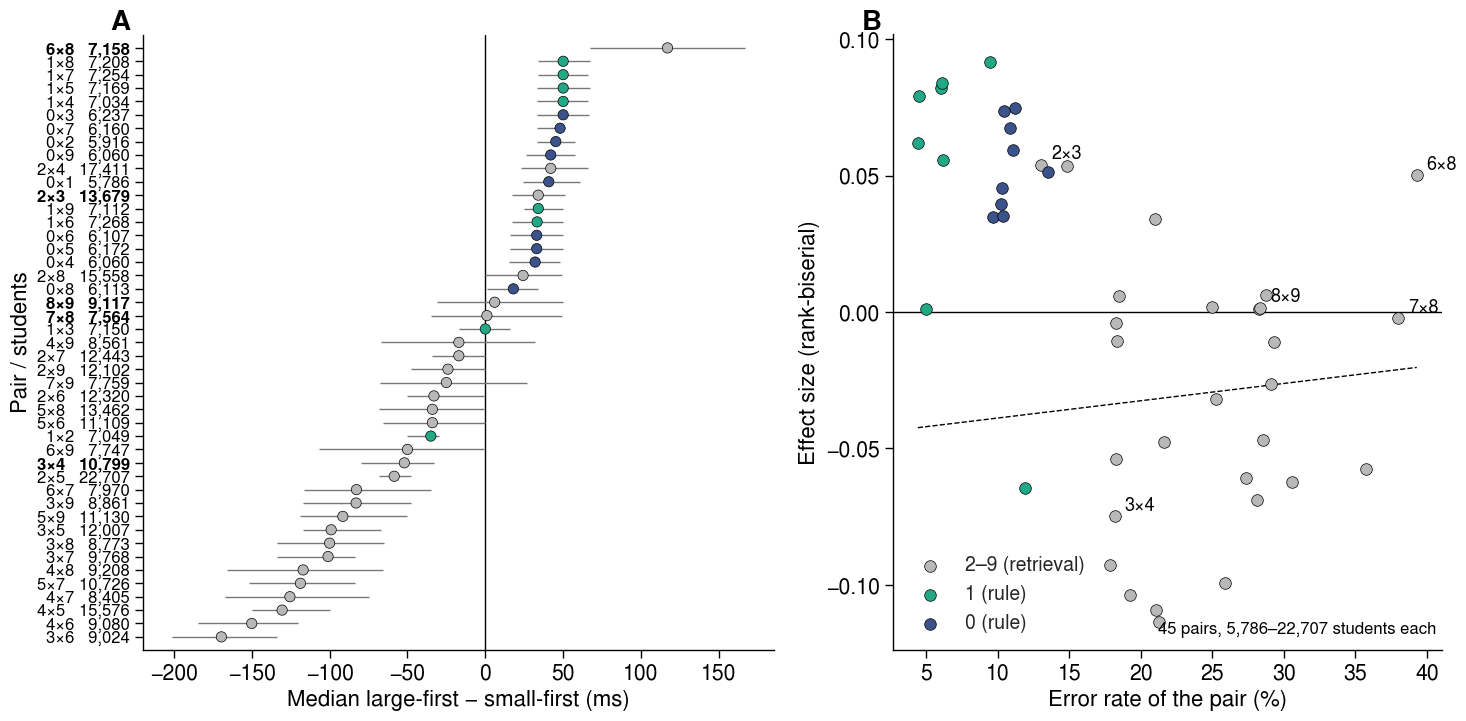

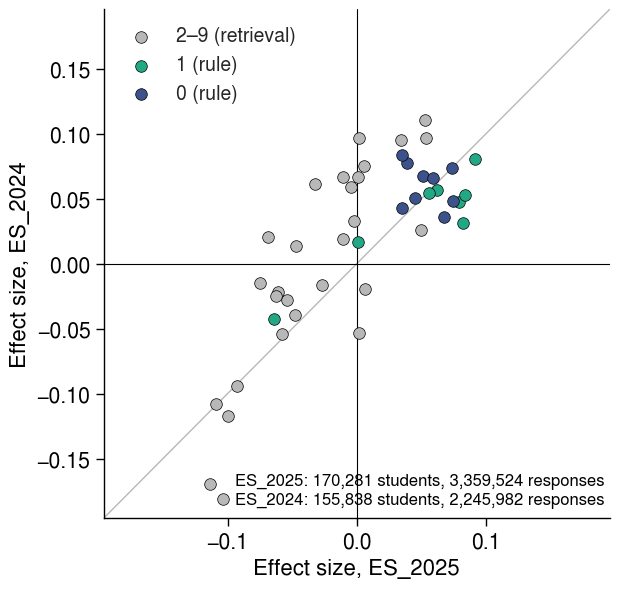

In [7]:
def pair_figure(P, trend, stem):
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 7.5), gridspec_kw={"width_ratios": [1.15, 1]})
    s = P.sort_values("med_diff_ms")
    ax.axvline(0, color="black", lw=1, zorder=1)
    ax.errorbar(s.med_diff_ms, np.arange(len(s)), xerr=np.vstack([s.med_diff_ms - 1000 * s.ci_lo,
                1000 * s.ci_hi - s.med_diff_ms]), fmt="none", ecolor="#777777", elinewidth=1, zorder=2)
    ax.scatter(s.med_diff_ms, np.arange(len(s)), s=55, color=[C_GROUP[g] for g in s.group],
               edgecolor="black", lw=.5, zorder=3)
    ax.set_yticks(np.arange(len(s)))
    ax.set_yticklabels([f"{p}   {n:,.0f}" for p, n in zip(s.index, s.students)], fontsize=FONT_MED - 4)
    for lab in ax.get_yticklabels():
        if lab.get_text().split()[0] in NAMED: lab.set_fontweight("bold")
    ax.set_ylim(-1, len(s)); ax.set_xlabel("Median large-first − small-first (ms)", fontsize=FONT_MED)
    ax.set_ylabel("Pair / students", fontsize=FONT_MED)

    ax2.axhline(0, color="black", lw=1, zorder=1)
    xs = np.linspace(P.error_rate.min(), P.error_rate.max(), 2)
    ax2.plot(xs, trend["intercept"] + trend["slope"] * xs, color="black", lw=1, ls="--", zorder=1)
    for name in (RETR, ONE, RULE):
        g = P[P.group.eq(name)]
        ax2.scatter(g.error_rate, g.r_rb, s=70, color=C_GROUP[name], edgecolor="black", lw=.5,
                    label=name.replace("-", "–"), zorder=2)
    for p in NAMED:
        ax2.annotate(p, (P.error_rate[p], P.r_rb[p]), textcoords="offset points",
                     xytext=(7, 4), fontsize=FONT_MED - 3, color="black")
    ax2.set_xlabel("Error rate of the pair (%)", fontsize=FONT_MED)
    ax2.set_ylabel("Effect size (rank-biserial)", fontsize=FONT_MED)
    ax2.text(.99, .02, f"{len(P)} pairs, {P.students.min():,.0f}–{P.students.max():,.0f} students each",
             transform=ax2.transAxes, ha="right", va="bottom", fontsize=FONT_MED - 4, color="black")
    ax2.legend(frameon=False, fontsize=FONT_MED - 2, loc="lower left")

    for a_, letter in [(ax, "A"), (ax2, "B")]:
        a_.text(-.02, 1.04, letter, transform=a_.transAxes, fontweight="bold", fontsize=FONT_BIG,
                va="top", ha="right", color="black")
        sns.despine(ax=a_)
    fig.tight_layout(); paint_it_black([ax, ax2])
    fig.savefig(PLOTS / f"{stem}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(PLOTS / f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)
    return fig

def replication_figure(j, stem):
    fig, ax = plt.subplots(figsize=(6.5, 6.2))
    lim = 1.08 * np.abs(j[[f"r_rb_{YEARS[0]}", f"r_rb_{YEARS[1]}"]].to_numpy()).max()
    ax.plot([-lim, lim], [-lim, lim], color="#B8B8B8", lw=1, zorder=1)
    ax.axhline(0, color="black", lw=.8, zorder=1); ax.axvline(0, color="black", lw=.8, zorder=1)
    for name in (RETR, ONE, RULE):
        g = j[j.group.eq(name)]
        ax.scatter(g[f"r_rb_{YEARS[0]}"], g[f"r_rb_{YEARS[1]}"], s=70, color=C_GROUP[name],
                   edgecolor="black", lw=.5, label=name.replace("-", "–"), zorder=2)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f"Effect size, {YEARS[0]}", fontsize=FONT_MED)
    ax.set_ylabel(f"Effect size, {YEARS[1]}", fontsize=FONT_MED)
    ax.text(.99, .02, chr(10).join(f"{y}: {R[y]['meta']['students']:,} students, "
                                   f"{R[y]['meta']['responses']:,} responses" for y in YEARS),
            transform=ax.transAxes, ha="right", va="bottom", fontsize=FONT_MED - 4, color="black")
    ax.legend(frameon=False, fontsize=FONT_MED - 2, loc="upper left")
    sns.despine(ax=ax); fig.tight_layout(); paint_it_black([ax])
    fig.savefig(PLOTS / f"{stem}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(PLOTS / f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)
    return fig

fig_main = pair_figure(pairs, trend[MAIN], f"rt_order_asymmetry_by_pair_{MAIN}")
pair_figure(R[YEARS[1]]["pairs"], trend[YEARS[1]], f"rt_order_asymmetry_by_pair_{YEARS[1]}")   # saved only
fig_rep = replication_figure(j, f"rt_order_asymmetry_replication_{YEARS[0]}_{YEARS[1]}")
display(fig_main, fig_rep)

## Sanity checks

In [8]:
for y in YEARS:
    P = R[y]["pairs"]
    assert len(P) == 45 and P.group.eq(RULE).sum() == 9 and P.group.eq(ONE).sum() == 8
    assert set(NAMED) <= set(P.index)
    assert P.students.min() > 500
assert R[YEARS[0]]["meta"]["responses"] > R[YEARS[1]]["meta"]["responses"]      # 2025 is the larger year
print("smallest pair per year:", {y: int(R[y]["pairs"].students.min()) for y in YEARS})
print("students per year:     ", {y: R[y]["meta"]["students"] for y in YEARS})

smallest pair per year: {'ES_2025': 5786, 'ES_2024': 2954}
students per year:      {'ES_2025': 170281, 'ES_2024': 155838}
